In [ ]:
import pandas as pd

# Load the CSV file from session storage
df = pd.read_csv('linear regression dataset.csv')

In [ ]:
# View the first 5 rows
print("First 5 rows:")
display(df.head())

# View dataset information (column names, data types, non-null counts)
print("\nDataset Info:")
df.info()

First 5 rows:


,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB


In [ ]:
# Summary statistics for numerical columns
df.describe()

,x,y
count,700.000000,699.000000
mean,54.985939,49.939869
std,134.681703,29.109217
min,0.000000,-3.839981
25%,25.000000,24.929968
50%,49.000000,48.973020
75%,75.000000,74.929911
max,3530.157369,108.871618


In [ ]:
# Drop missing values
df_clean = df.dropna().copy()

# Remove extreme outlier in x (e.g., x > 100)
df_clean = df_clean[df_clean['x'] <= 100]

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Define feature (X) and target (y)
X = df_clean[['x']]
y = df_clean['y']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Print model slope and intercept
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (Coefficient): 1.0012167598754458
Intercept: -0.09664630862199175


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate metrics
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))

R² Score: 0.9910998765243975
Mean Squared Error (MSE): 7.752986666319193


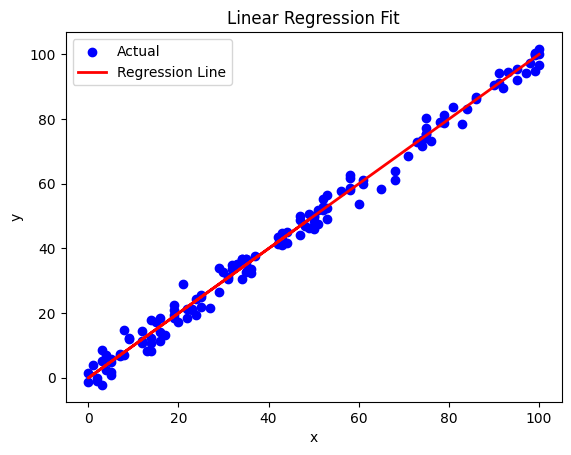

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

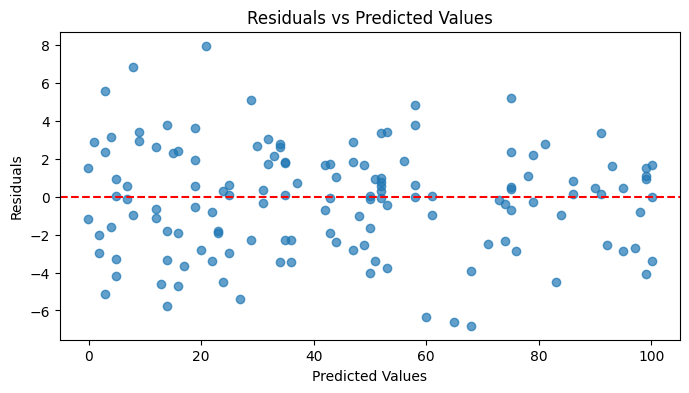

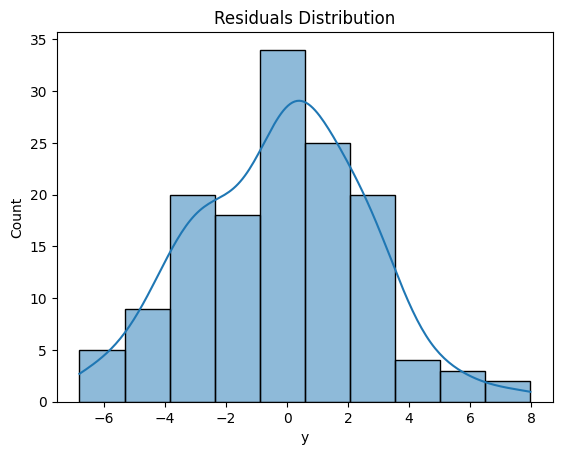

In [ ]:
import seaborn as sns

# Calculate residuals
residuals = y_test - y_pred

# Residual plot
plt.figure(figsize=(8, 4))
plt.axhline(0, color='red', linestyle='--')
plt.scatter(y_pred, residuals, alpha=0.7)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

# Distribution of residuals
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

In [ ]:
import numpy as np

# Define new x values to predict
new_x = np.array([[15], [45], [90]])

# Predict y values
predictions = model.predict(new_x)

for x_val, pred in zip(new_x.flatten(), predictions):
    print(f"For x = {x_val}, predicted y = {pred:.2f}")

For x = 15, predicted y = 14.92
For x = 45, predicted y = 44.96
For x = 90, predicted y = 90.01


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Create quadratic features (x^2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Fit polynomial regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Evaluate polynomial model
y_poly_pred = poly_model.predict(X_test_poly)
print("Polynomial R² Score:", r2_score(y_test, y_poly_pred))

Polynomial R² Score: 0.9910566816419998


In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("5-Fold R² Scores:", scores)
print("Mean R² Score:", scores.mean())

5-Fold R² Scores: [0.9887418  0.98975303 0.9922575  0.99023067 0.99089936]
Mean R² Score: 0.9903764720252457


In [ ]:
import pickle

# Save the model to session storage
with open('linear_regression_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Load the saved model back
with open('linear_regression_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Test the loaded model
print("Loaded model prediction for x = 50:", loaded_model.predict([[50]])[0])

Loaded model prediction for x = 50: 49.9641916851503


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.linear_model import Ridge, Lasso

# Ridge Regression (L2 Penalty)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print("Ridge R² Score:", ridge.score(X_test, y_test))

# Lasso Regression (L1 Penalty)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
print("Lasso R² Score:", lasso.score(X_test, y_test))

Ridge R² Score: 0.9910998868870696
Lasso R² Score: 0.9911004396417725


In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Absolute Error (MAE): 2.2021
Root Mean Squared Error (RMSE): 2.7844


In [ ]:
# Create a results DataFrame
results = X_test.copy()
results['Actual_y'] = y_test
results['Predicted_y'] = y_pred
results['Absolute_Error'] = abs(y_test - y_pred)

# Export to CSV
results.to_csv('linear_regression_predictions.csv', index=False)
print("Predictions saved to 'linear_regression_predictions.csv'")
display(results.head())

Predictions saved to 'linear_regression_predictions.csv'


,x,Actual_y,Predicted_y,Absolute_Error
158,100.0,96.623279,100.025030,3.401751
500,97.0,94.296334,97.021379,2.725045
397,12.0,14.558961,11.917955,2.641007
155,86.0,86.821321,86.007995,0.813326
322,91.0,94.367790,91.014079,3.353711
